# CONFUSION MATRIX

|                 | **Predicted: No**   | **Predicted: Yes**  |
| --------------- | ------------------- | ------------------- |
| **Actual: No**  | True Negative (TN)  | False Positive (FP) |
| **Actual: Yes** | False Negative (FN) | True Positive (TP)  |


 What the Terms Mean:
 
TP (True Positive): Correctly predicted "Yes" (e.g., correctly predicted spam).

TN (True Negative): Correctly predicted "No" (e.g., correctly predicted not spam).

FP (False Positive): Predicted "Yes" but was actually "No" (e.g., marked a good email as spam).

FN (False Negative): Predicted "No" but was actually "Yes" (e.g., missed a spam email).



In [1]:
from sklearn.metrics import confusion_matrix

y_true = [1, 0, 1, 1, 0, 1, 0]
y_pred = [1, 0, 1, 0, 0, 1, 1]

confusion_matrix(y_true, y_pred)


array([[2, 1],
       [1, 3]], dtype=int64)

Which means:

2 True Negatives (TN)

3 True Positives (TP)

1 False Negative (FN)

1 False Positive (FP)


# A classification report provides more detailed metrics than just a confusion matrix.

| Metric        | Description                                                 |
| ------------- | ----------------------------------------------------------- |
| **Precision** | Of all predicted positives, how many were correct?          |
| **Recall**    | Of all actual positives, how many did we correctly predict? |
| **F1-Score**  | Harmonic mean of Precision and Recall. Balances both.       |
| **Support**   | Number of true instances for each class.                    |


📘 Definitions:

Precision = TP / (TP + FP)

High precision = low false positives.

Recall = TP / (TP + FN)

High recall = low false negatives.

F1 Score = 2 × (Precision × Recall) / (Precision + Recall)

Good when classes are imbalanced.



In [2]:
from sklearn.metrics import classification_report

y_true = [1, 0, 1, 1, 0, 1, 0]
y_pred = [1, 0, 1, 0, 0, 1, 1]

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.75      0.75      0.75         4

    accuracy                           0.71         7
   macro avg       0.71      0.71      0.71         7
weighted avg       0.71      0.71      0.71         7



| Metric        | Tells You…                                    |
| ------------- | --------------------------------------------- |
| **Accuracy**  | Overall correctness (TP + TN) / total         |
| **Precision** | How reliable a positive prediction is         |
| **Recall**    | How well positives are captured               |
| **F1-Score**  | Combined balance between precision and recall |
| **Support**   | Number of samples in each class               |


# Dataset: Iris Flower Dataset

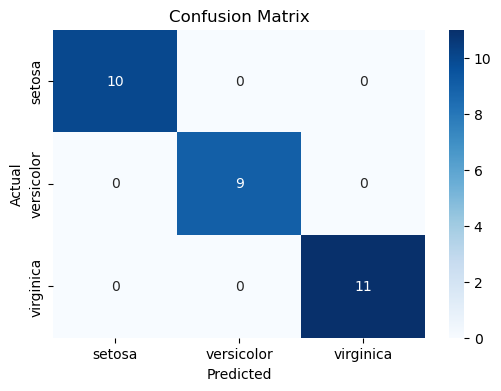

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("Classification Report:\n", report)


# TITANIC DATASET


Confusion Matrix:
 [[73  7]
 [23 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.91      0.83        80
           1       0.85      0.63      0.73        63

    accuracy                           0.79       143
   macro avg       0.81      0.77      0.78       143
weighted avg       0.80      0.79      0.78       143



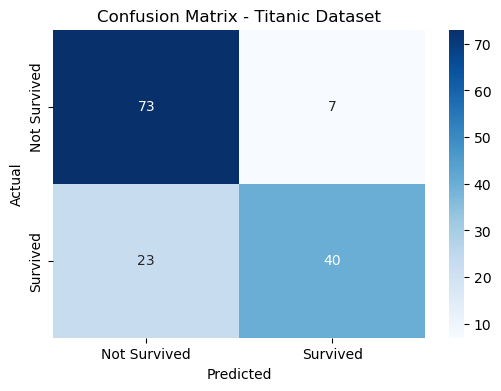

In [4]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic dataset from seaborn
titanic = sns.load_dataset('titanic')

# Drop rows with missing values in important columns
titanic = titanic.dropna(subset=['age', 'embarked', 'fare', 'sex', 'pclass', 'survived'])

# Encode categorical variables
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Select features and target
X = titanic[['pclass', 'sex', 'age', 'fare', 'embarked']]
y = titanic['survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Titanic Dataset')
plt.show()


https://www.kaggle.com/code/nargisbegum82/confusion-matrix-in-machine-learning/notebook